### Base reference: https://github.com/OpenAI/CLIP

In [ ]:
!pip install ftfy regex tqdm && pip install git+https://github.com/openai/CLIP.git

In [1]:
import os
import clip
import torch
from torchvision.datasets import CIFAR100

# Load the model
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load('ViT-B/32', device)

100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 74.0MiB/s]


In [2]:
# Download the dataset
cifar100 = CIFAR100(root=os.path.expanduser("."), download=True, train=False)

100%|██████████| 169M/169M [00:04<00:00, 36.6MB/s]


In [17]:
# Prepare the inputs
image, class_id = cifar100[2000]
image_input = preprocess(image).unsqueeze(0).to(device)
text_inputs = torch.cat([clip.tokenize(f"a photo of a {c}") for c in cifar100.classes]).to(device)

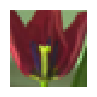

In [18]:
import matplotlib.pyplot as plt

# Visualize the input image
plt.figure(figsize=(1, 1))
plt.imshow(image, interpolation='nearest')
plt.axis('off')
plt.show()

In [19]:
# Calculate features
with torch.no_grad():
    image_features = model.encode_image(image_input)
    text_features = model.encode_text(text_inputs)

# Pick the top 5 most similar labels for the image
image_features /= image_features.norm(dim=-1, keepdim=True)
text_features /= text_features.norm(dim=-1, keepdim=True)
similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
values, indices = similarity[0].topk(5)

# Print the result
print("\nTop predictions:\n")
for value, index in zip(values, indices):
    print(f"{cifar100.classes[index]:>16s}: {100 * value.item():.2f}%")


Top predictions:

           tulip: 93.31%
          orchid: 2.19%
    sweet_pepper: 0.83%
            rose: 0.71%
           poppy: 0.56%
